<a href="https://colab.research.google.com/github/benjaminqq-12/Inteligencia-Artificial-2026-2/blob/main/E2-Regresion/E2_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
print(pd.__version__)

2.2.3


In [2]:
!wget https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E2-Regresion/clientes_mrr_dataset.csv

--2026-09-30 04:30:25--  https://raw.githubusercontent.com/benjaminqq-12/Inteligencia-Artificial-2026-2/refs/heads/main/E2-Regresion/clientes_mrr_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3527824 (3.4M) [text/plain]
Saving to: ‘clientes_mrr_dataset.csv’

clientes_mrr_datase 100%[===================>]   3.36M  --.-KB/s    in 0.07s   

2026-09-30 04:30:26 (48.4 MB/s) - ‘clientes_mrr_dataset.csv’ saved [3527824/3527824]



In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [4]:
data = pd.read_csv('clientes_mrr_dataset.csv')
data.head()

,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,706.16
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,555.95
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,755.53
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,364.94
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1611.93


In [6]:
null_summary = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print(null_summary[null_summary["Nulos_Absolutos"] > 0])
print("\n")

                       Nulos_Absolutos  Porcentaje_Nulos
tickets_soporte                   2464              8.21
promedio_sesiones_mes             1545              5.15
satisfaccion_nps                  3597             11.99




### Revisión de Tipos de Datos y Conversión

Primero, vamos a revisar los tipos de datos de cada columna y convertir 'fecha_registro' a un formato de fecha y hora adecuado.

In [7]:
print(data.info())

# Convertir 'fecha_registro' a tipo datetime
data['fecha_registro'] = pd.to_datetime(data['fecha_registro'])

print('\nTipos de datos después de la conversión:')
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB
None

Tipos de datos después de la conversión:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Co

### Análisis de Variables Categóricas

Vamos a verificar los valores únicos en las columnas categóricas para identificar posibles inconsistencias o la necesidad de codificación.

In [9]:
print('Valores únicos en sector_empresa:', data['sector_empresa'].unique())
print('Valores únicos en tamano_empresa:', data['tamano_empresa'].unique())
print('Valores únicos en duracion_contrato:', data['duracion_contrato'].unique())
print('Valores únicos en pago_puntual:', data['pago_puntual'].unique())

Valores únicos en sector_empresa: ['Finanzas' 'Tecnologia' 'Educacion' 'Salud' 'Retail']
Valores únicos en tamano_empresa: ['Mediana' 'Pequeña' 'Grande']
Valores únicos en duracion_contrato: ['Mensual' '2 Años' 'Anual']
Valores únicos en pago_puntual: ['Si' 'No']


### Detección de Sesgos y Outliers en Variables Numéricas

Ahora, analizaremos las variables numéricas para detectar sesgos y la presencia de valores atípicos (outliers) utilizando boxplots, histogramas y la medida de asimetría (skewness).

In [10]:
numerical_cols = [
    'tickets_soporte',
    'promedio_sesiones_mes',
    'satisfaccion_nps',
    'gasto_mkt_asociado',
    'mrr_proximo_trimestre'
]

# Descripción estadística de las columnas numéricas
print('Descripción estadística de variables numéricas:')
print(data[numerical_cols].describe())

# Calcular asimetría (skewness)
print('\nAsimetría (Skewness) de variables numéricas:')
print(data[numerical_cols].skew())

Descripción estadística de variables numéricas:
       tickets_soporte  promedio_sesiones_mes  satisfaccion_nps  \
count     27536.000000           28455.000000      26403.000000   
mean          3.005121              50.130595          5.913911   
std           1.734139              45.058935          2.312062   
min           0.000000               5.001555          1.000000   
25%           2.000000              18.086442          4.000000   
50%           3.000000              36.230789          6.000000   
75%           4.000000              67.451126          8.000000   
max          12.000000             430.701397         10.000000   

       gasto_mkt_asociado  mrr_proximo_trimestre  
count        30000.000000           30000.000000  
mean          2551.090539             710.926286  
std           1416.112727             337.688948  
min            100.355894              50.000000  
25%           1330.525002             458.985000  
50%           2541.073850             642.

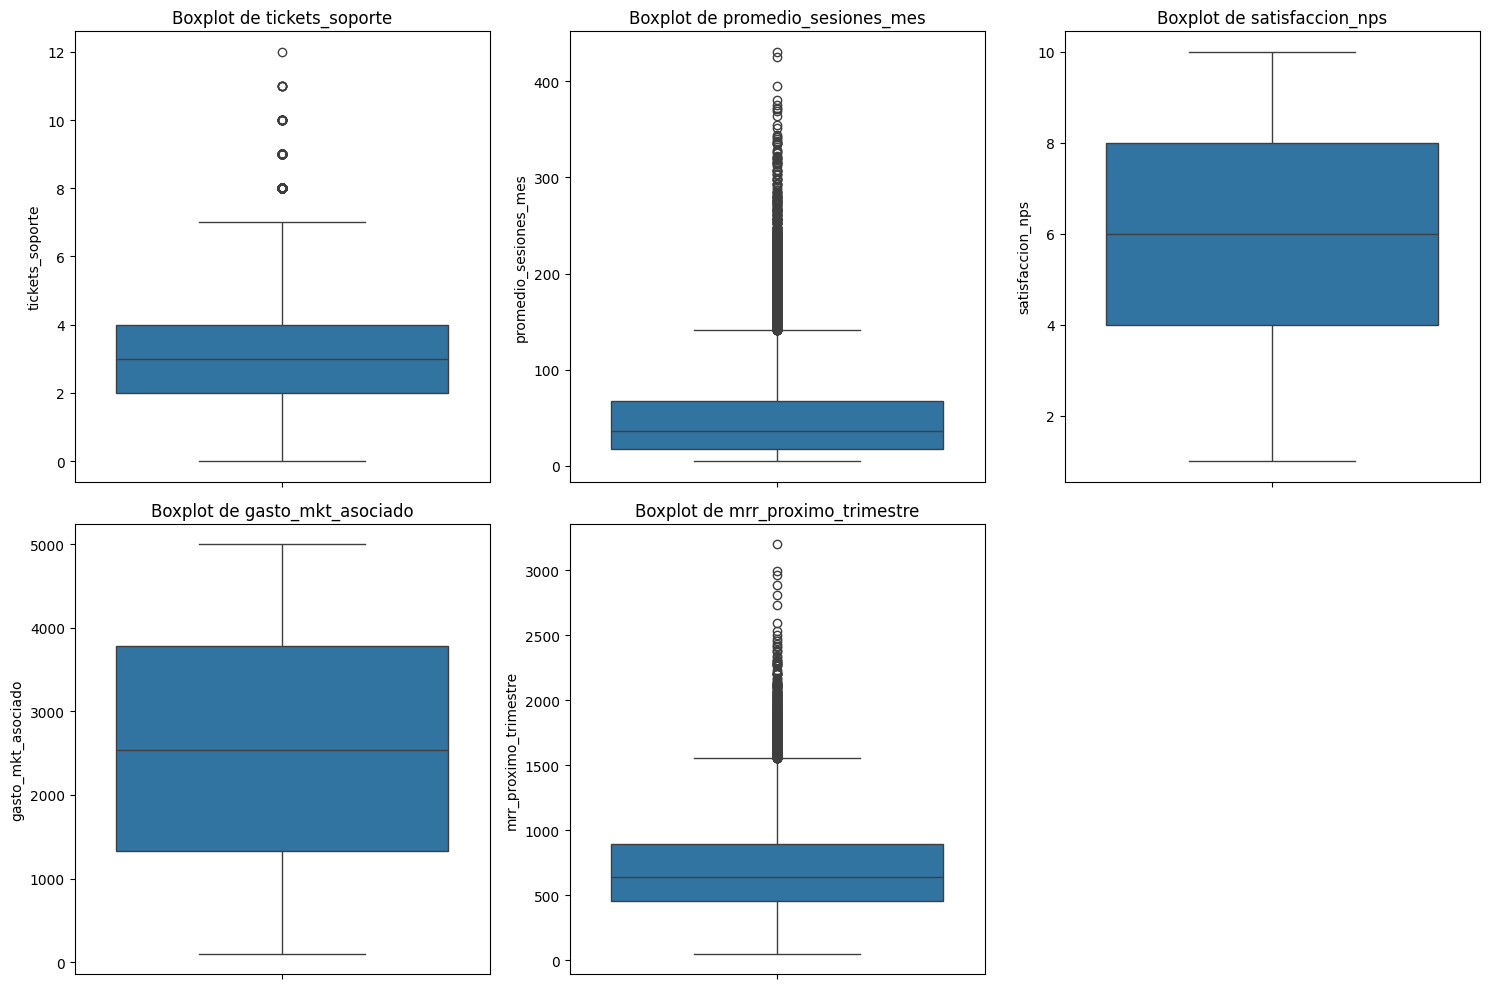

In [11]:
# Boxplots para detectar outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sb.boxplot(y=data[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

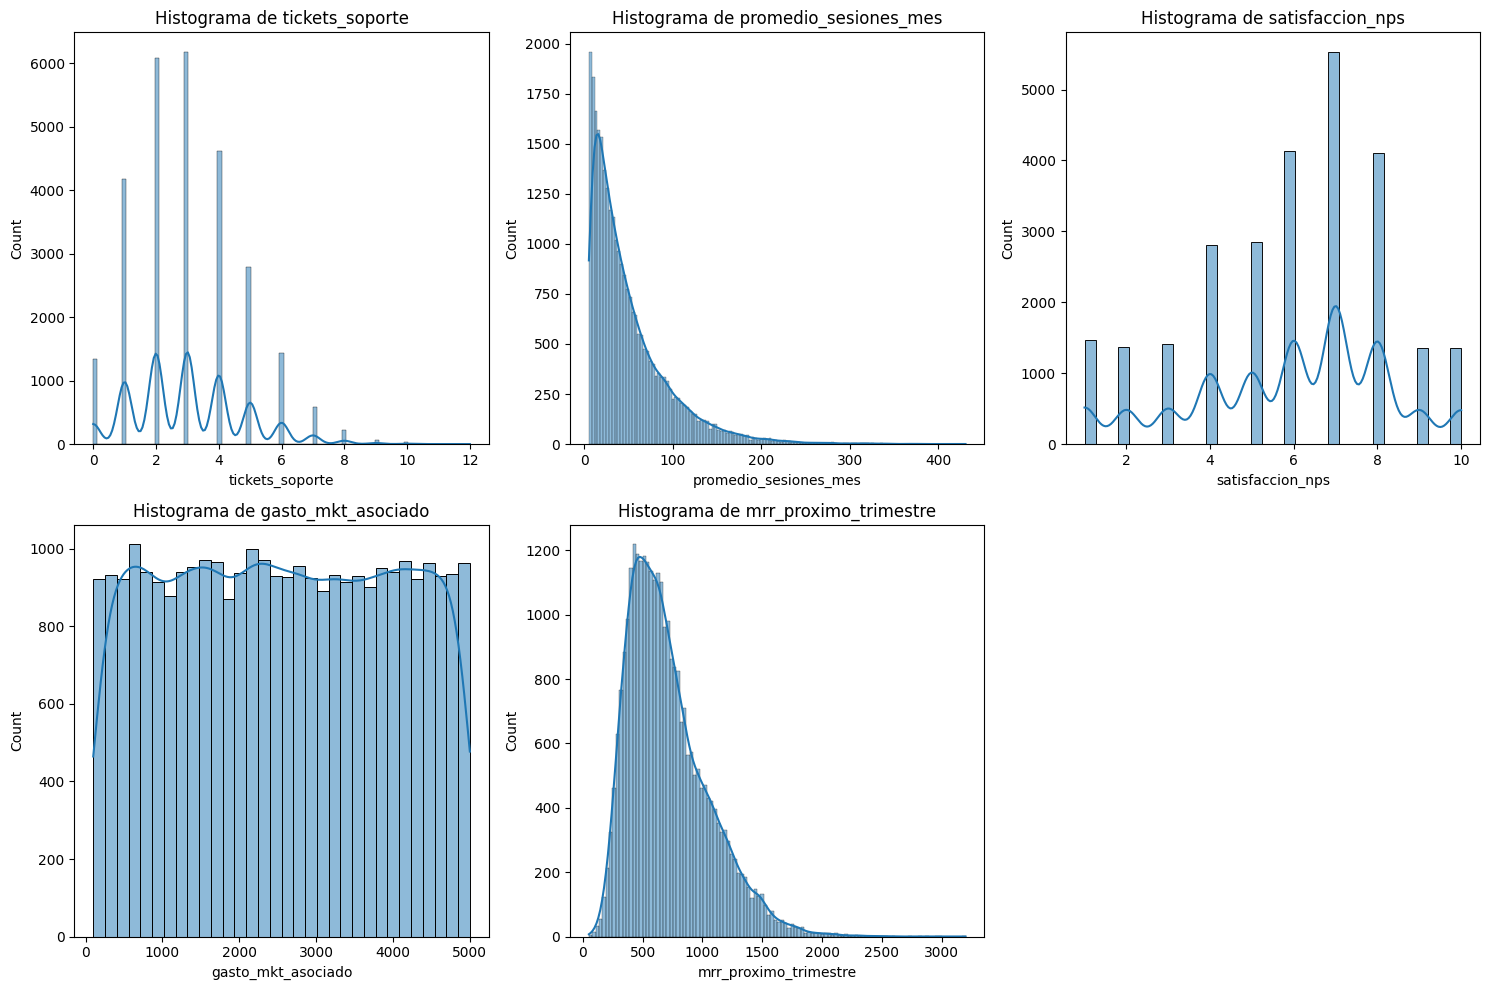

In [12]:
# Histogramas para visualizar la distribución y sesgos
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sb.histplot(data[col].dropna(), kde=True)
    plt.title(f'Histograma de {col}')
plt.tight_layout()
plt.show()